In [1]:
import pandas as pd 
import glob 
import analysis_utils
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from pymol import cmd

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f_oneway


/vol/ek/Home/tomertsa/miniforge3/envs/local_python_playground/lib/python3.12/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
# path to jacobian contact npy files 
path_to_jacobian_contacts = "/vol/ek/Home/tomertsa/projects/signal_peptide/chs_refseq_approach/results/sp_and_del_jac_contacts_results"

# read in aligned_sp_and_deletion isoform tables 
sp_and_del = pd.read_table('aligned_sp_and_deletion_isoform_mane_table_220225.tsv',sep='\t')

# read in formatted sp_and_del mane_isoform paired table 
struct_del_align_results = pd.read_table('struct_del_align_results_150425.tsv',sep='\t')
filt_struct_del_ss2 = pd.read_table('struct_del_align_ss2_results_150425.tsv',sep='\t')

# read in the chs fasta table and change CHS_ID to index 
chs_fasta_table = pd.read_table('../parsing_and_data_analysis/chs_fasta_table.tsv',sep='\t')
human_sp_chs_fasta_tab = pd.read_table("../results/human_sp_chs_fasta_table.tsv",sep='\t')

chs_fasta_table.set_index('CHESS_ID',inplace=True)

inclusive_sp_general_tab = pd.read_table('inclusive_sp_general_tab_120125_struct_role_domain_completion_ipynb.tsv',sep='\t')

# path to chess db pdb files
chess_path = "/sci/labs/fora/share/databases/CHESS_v3_db/pdb_v1.3"


In [3]:

def matrix_to_df(matrix):
    # Convert matrix to numpy array if it isn't already
    matrix = np.array(matrix)
    
    # Get dimensions
    rows, cols = matrix.shape
    
    # Create indices for all positions
    i, j = np.indices((rows, cols))

    # Create dataframe
    df = pd.DataFrame({
        'i': i.flatten(),
        'j': j.flatten(),
        'value': matrix.flatten()
    })
    
    # fix index offsetting 
    df.i = df.i.add(1)
    df.j = df.j.add(1)
    
    return df

def get_top_L_matrix_values(matrix, L, n_factor):
    # Ensure the matrix is numpy array
    matrix = np.array(matrix)
    
    # Since matrix is symmetric, we only need unique values
    # Get upper triangle values (excluding (i,i) diagonal, using diag_val argument)
    diag_val = 1 
    upper_tri = matrix[np.triu_indices(len(matrix),diag_val)]
    
    # Get L-th highest value as threshold
    # L(protein length)*n_factor = top LN interactions 
    
    top_LN = round(L*n_factor)
    
    if top_LN < len(upper_tri):
        threshold = sorted(upper_tri, reverse=True)[top_LN]
    else:
        print('LN larger than upper tri')
        threshold = matrix  # If L is larger than number of elements, return original
    
    # Create a copy and set values below threshold to 0
    filtered = np.where(matrix >= threshold, 1, 0)
    print(filtered)
    return filtered


def read_in_jac_contacts(aligned_mane, aligned_iso):
    mane_jac_cont = np.load(path_to_jacobian_contacts+"/"+aligned_mane+'_jac_contacts.npy')
    iso_jac_cont = np.load(path_to_jacobian_contacts+"/"+aligned_iso+'_jac_contacts.npy')
    
    return mane_jac_cont, iso_jac_cont


def detect_meaningful_coevo_pairs(jac_contacts, quant_value):
    contacts_df = matrix_to_df(jac_contacts)
    print('top_L jac_contacts for detect')
    print(jac_contacts)
    print(contacts_df)
    
    prot_len = int(jac_contacts.shape[0])
    
    threshold = contacts_df['value'].quantile(quant_value)
    high_values = contacts_df[contacts_df['value'] >= threshold]
    
  
    top_filt = high_values.sort_values(by='value', ascending = False)
    print('top filtered values')
    print(top_filt)
#     full_df = mane_jac_df.sort_values(by='value', ascending=False)
    return top_filt


def map_sp_coevo(aligned_id, coevo_df, sp_end, L):
    # categorize and count jacobian pairs in the SP, domain regions
    
    sp_positions = [x+1 for x in range(sp_end)]
    
    # keep only rows where i is within the sp segment
    sp_i_df = coevo_df[coevo_df.i.isin(sp_positions)]
    
    within_sp_pairs = sp_i_df[sp_i_df.j.isin(sp_positions)]
    sp_to_domain_pairs = sp_i_df[~sp_i_df.j.isin(sp_positions)]
    
    within_sp_pairs_count = len(within_sp_pairs)
    sp_to_domain_pairs_count = len(sp_to_domain_pairs)
    
    total_sp_pairs = len(sp_i_df)
    
    sp_domain_potential = sp_end * (L - sp_end) 
    ### then normalize by sp_domain_potential
    
    norm_sp_to_domain_pairs = sp_to_domain_pairs_count / sp_domain_potential
    print('co_evo df')
    print(coevo_df)
    print("### validation of sp_coevo")
    print(L)
    print(sp_end)
    print("sp_positions")
    print(sp_positions)
    print("within length")
    print(within_sp_pairs_count)
    print("sp_dom length")
    print(sp_to_domain_pairs_count)
    print('sp_domain_potential')
    print(sp_domain_potential)

    
    
    sp_co_evo = {
        'aligned_id': aligned_id, 
        'corrected_sp': sp_end, 
        'within_sp_pairs': within_sp_pairs_count,
        'sp_to_domain_pairs': sp_to_domain_pairs_count,
        'total_sp_pairs': total_sp_pairs, 
        'norm_sp_to_domain_pairs': norm_sp_to_domain_pairs
        
    }
    
    return sp_co_evo
        
    
def sp_func(aligned_mane, aligned_iso, corrected_mane_sp, corrected_iso_sp, n_factor=15, quant_val=0):
    
    # get mane_jac and iso_jac contacts
    mane_jac_contacts, iso_jac_contacts = read_in_jac_contacts(aligned_mane, aligned_iso) 
    
    # get top L*n_factor
    mane_len = mane_jac_contacts.shape[0]
    print(mane_len)
    top_L_mane_jac = get_top_L_matrix_values(mane_jac_contacts, mane_len, n_factor)
    
    iso_len = iso_jac_contacts.shape[0]
    print(iso_len)
    top_L_iso_jac = get_top_L_matrix_values(iso_jac_contacts, iso_len, n_factor)
    
    # save out the top_L matrices 
    mane_output_name = aligned_mane + '_' + 'top_L_jac_contacts_matrix_n_factor_'+str(n_factor)+'_quant_'+str(quant_val)
    iso_output_name = aligned_iso + '_' + 'top_L_jac_contacts_matrix_n_factor_'+str(n_factor)+'_quant_'+str(quant_val)
    
    np.save(mane_output_name+'.npy', top_L_mane_jac)
    np.save(iso_output_name+'.npy', top_L_iso_jac)
    
    mane_filt_df = detect_meaningful_coevo_pairs(top_L_mane_jac, quant_val)
    print('mane_filt_df')
    print(mane_filt_df)
    mane_selected_pairs = mane_filt_df.query('value == 1')
    print('mane_selected_pairs')
    print(mane_selected_pairs)
    mane_sp_co_evo_counts = map_sp_coevo(aligned_mane, mane_selected_pairs, corrected_mane_sp, mane_len)

    
    iso_filt_df = detect_meaningful_coevo_pairs(top_L_iso_jac, quant_val)
    iso_selected_pairs = iso_filt_df.query('value == 1')
    print('iso_selected_pairs')
    print(iso_selected_pairs)
    iso_sp_co_evo_counts = map_sp_coevo(aligned_iso, iso_selected_pairs, corrected_iso_sp, iso_len)
   

    # save out co_evo tables 
    mane_filt_df.to_csv(mane_output_name+'.tsv', sep='\t')
    iso_filt_df.to_csv(iso_output_name+'.tsv', sep='\t')
    
    return mane_sp_co_evo_counts, iso_sp_co_evo_counts

    
    

(array([62.,  0.,  0.,  5.,  4.,  1.,  2.,  1.,  2.,  7.]),
 array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20.]),
 <BarContainer object of 10 artists>)

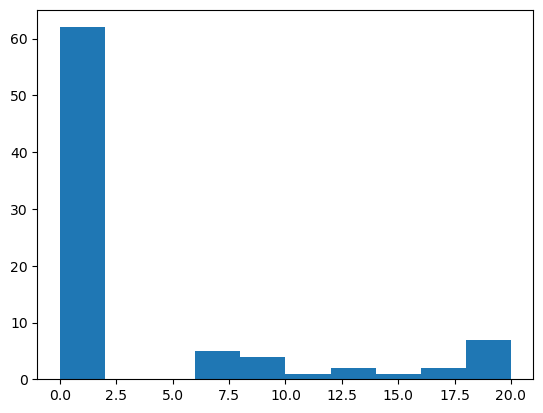

In [4]:
# plot the min_rmsd column values (min_rmsd == alignment between isoform and canonical, complementing or not)
# struct_del_align_results.min_rmsd.replace([np.inf, -np.inf], 10, inplace=True)
plt.hist(filt_struct_del_ss2.min_rmsd, range=(0,20))

In [5]:
# # compute the jacobian changes in sp and sp-to-domain regions for both mane and isoforms 
# sp_pairs_dicts = filt_struct_del_ss2.apply(lambda row: sp_func(row['aligned_mane'], row['aligned_iso'], \
#                                    row['corrected_mane_sp'], row['corrected_iso_sp']), axis=1)


# # make one table for plotting out of the pair dictionaries

# pair_tab_list = []

# for i in range(len(sp_pairs_dicts)):
#     pair_tab_list.append(pd.DataFrame(sp_pairs_dicts[i]))
    
# pair_tab = pd.concat(pair_tab_list)

# # align mane and iso in one row
# mane_jac_tab = pair_tab.query('index==0')
# mane_jac_tab.columns = ['mane_'+i for i in mane_jac_tab.columns]

# iso_jac_tab = pair_tab.query('index==1')
# iso_jac_tab.columns = ['iso_'+i for i in iso_jac_tab.columns]

# mane_jac_tab.reset_index(inplace=True)
# iso_jac_tab.reset_index(inplace=True)

# mane_iso_jac_tab = pd.concat([mane_jac_tab, iso_jac_tab], axis=1).drop(['index'], axis=1)
# mane_iso_jac_tab.columns = mane_iso_jac_tab.columns.str.replace('mane_aligned_id','aligned_mane')
# mane_iso_jac_tab.columns = mane_iso_jac_tab.columns.str.replace('iso_aligned_id','aligned_iso')


# # add a column of complementary \ non complementary
# comp_column = filt_struct_del_ss2[['aligned_mane','aligned_iso','GENE','complementary']]
# mane_iso_jac_tab = mane_iso_jac_tab.merge(comp_column, on=['aligned_mane','aligned_iso'])

# # add a ratio of sp_to_domain_pairs (iso divided by canonical)
# mane_iso_jac_tab['sp_to_domain_ratio'] = mane_iso_jac_tab.apply(lambda row: round(row['iso_sp_to_domain_pairs'] / row['mane_sp_to_domain_pairs'], 3), axis=1)

# mane_iso_jac_tab.to_csv('mane_iso_jac_comparison_table_150425.tsv',sep='\t',index=False)

CHS.35724.4
CHS.35724.alt100
398
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
380
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
top_L jac_contacts for detect
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
          i    j  value
0         1    1      0
1         1    2      1
2         1    3      1
3         1    4      1
4         1    5      1
...     ...  ...    ...
158399  398  394      1
158400  398  395      1
158401  398  396      1
158402  398  397      1
158403  398  398      0

[158404 rows x 3 columns]
top filtered values
         i    j  value
93345  235  214      1
93346  235  215      1
93347  235  216      1
93349  235  218      1
93350  235  219      1
...    ...  ...    ...
55186  139  263      0
55187  139  264      0
55188  139  265      0
55189  1

CHS.35724.4
CHS.35724.5
398
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
380
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
top_L jac_contacts for detect
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
          i    j  value
0         1    1      0
1         1    2      1
2         1    3      1
3         1    4      1
4         1    5      1
...     ...  ...    ...
158399  398  394      1
158400  398  395      1
158401  398  396      1
158402  398  397      1
158403  398  398      0

[158404 rows x 3 columns]
top filtered values
         i    j  value
93345  235  214      1
93346  235  215      1
93347  235  216      1
93349  235  218      1
93350  235  219      1
...    ...  ...    ...
55186  139  263      0
55187  139  264      0
55188  139  265      0
55189  139  2

CHS.53322.4
CHS.53322.6
635
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
571
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
top_L jac_contacts for detect
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
          i    j  value
0         1    1      0
1         1    2      1
2         1    3      1
3         1    4      1
4         1    5      1
...     ...  ...    ...
403220  635  631      1
403221  635  632      1
403222  635  633      1
403223  635  634      1
403224  635  635      0

[403225 rows x 3 columns]
top filtered values
          i    j  value
403211  635  622      1
403208  635  619      1
9         1   10      1
403212  635  623      1
403213  635  624      1
...     ...  ...    ...
19048    30  634      0
19017    30  603      0
19018    30  604      0
190

CHS.55258.1
CHS.55258.3
1124
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
976
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
top_L jac_contacts for detect
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
            i     j  value
0           1     1      0
1           1     2      1
2           1     3      1
3           1     4      1
4           1     5      1
...       ...   ...    ...
1263371  1124  1120      1
1263372  1124  1121      1
1263373  1124  1122      1
1263374  1124  1123      1
1263375  1124  1124      0

[1263376 rows x 3 columns]
top filtered values
          i    j  value
124865  112  102      1
124866  112  103      1
124867  112  104      1
124868  112  105      1
124869  112  106      1
...     ...  ...    ...
427197  381   78      0
427196  381  

top filtered values
         i    j  value
35210  115   99      1
35214  115  103      1
35215  115  104      1
35216  115  105      1
35217  115  106      1
...    ...  ...    ...
37500  122  233      0
37499  122  232      0
37498  122  231      0
37497  122  230      0
37507  122  240      0

[94864 rows x 3 columns]
mane_filt_df
         i    j  value
35210  115   99      1
35214  115  103      1
35215  115  104      1
35216  115  105      1
35217  115  106      1
...    ...  ...    ...
37500  122  233      0
37499  122  232      0
37498  122  231      0
37497  122  230      0
37507  122  240      0

[94864 rows x 3 columns]
mane_selected_pairs
         i    j  value
35210  115   99      1
35214  115  103      1
35215  115  104      1
35216  115  105      1
35217  115  106      1
...    ...  ...    ...
5548    19    5      1
5552    19    9      1
8030    27   23      1
5551    19    8      1
8029    27   22      1

[9242 rows x 3 columns]
co_evo df
         i    j  value
35210  11

...

co_evo df
          i    j  value
1         1    2      1
246995  497  484      1
246996  497  485      1
246997  497  486      1
246998  497  487      1
...     ...  ...    ...
13        1   14      1
14        1   15      1
16        1   17      1
246983  497  472      1
246987  497  476      1

[14912 rows x 3 columns]
### validation of sp_coevo
497
23
sp_positions
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
within length
498
sp_dom length
308
sp_domain_potential
10902
CHS.6541.3
CHS.6541.10
262
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
184
[[0 1 1 ... 1 0 1]
 [1 0 1 ... 1 0 1]
 [1 1 0 ... 0 0 0]
 ...
 [1 1 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [1 1 0 ... 1 1 0]]
top_L jac_contacts for detect
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
         i    j  value
0        1    1      0
1        1    2 

CHS.1219.8
CHS.1219.alt109
379
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
233
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
top_L jac_contacts for detect
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
          i    j  value
0         1    1      0
1         1    2      1
2         1    3      1
3         1    4      1
4         1    5      1
...     ...  ...    ...
143636  379  375      1
143637  379  376      1
143638  379  377      1
143639  379  378      1
143640  379  379      0

[143641 rows x 3 columns]
top filtered values
          i    j  value
143625  379  364      1
143624  379  363      1
9         1   10      1
143626  379  365      1
143627  379  366      1
...     ...  ...    ...
11381    31   12      0
11382    31   13      0
11383    31   14      0


top filtered values
         i    j  value
49253   95   92      1
49252   95   91      1
49251   95   90      1
49250   95   89      1
49249   95   88      1
...    ...  ...    ...
93839  180  223      0
93838  180  222      0
93837  180  221      0
93836  180  220      0
93844  180  228      0

[273529 rows x 3 columns]
mane_filt_df
         i    j  value
49253   95   92      1
49252   95   91      1
49251   95   90      1
49250   95   89      1
49249   95   88      1
...    ...  ...    ...
93839  180  223      0
93838  180  222      0
93837  180  221      0
93836  180  220      0
93844  180  228      0

[273529 rows x 3 columns]
mane_selected_pairs
          i    j  value
49253    95   92      1
49252    95   91      1
49251    95   90      1
49250    95   89      1
49249    95   88      1
...     ...  ...    ...
209053  400  377      1
233708  447  451      1
178668  342  326      1
230542  441  423      1
45571    88   71      1

[15692 rows x 3 columns]
co_evo df
          i    j 

CHS.16035.12
CHS.16035.3
523
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
484
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
top_L jac_contacts for detect
[[0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]
          i    j  value
0         1    1      0
1         1    2      1
2         1    3      1
3         1    4      1
4         1    5      1
...     ...  ...    ...
273524  523  519      1
273525  523  520      1
273526  523  521      1
273527  523  522      1
273528  523  523      0

[273529 rows x 3 columns]
top filtered values
         i    j  value
49253   95   92      1
49252   95   91      1
49251   95   90      1
49250   95   89      1
49249   95   88      1
...    ...  ...    ...
93839  180  223      0
93838  180  222      0
93837  180  221      0
93836  180  

top filtered values
        i    j  value
13833  57   58      1
13834  57   59      1
13835  57   60      1
13836  57   61      1
13837  57   62      1
...    ..  ...    ...
21848  89  201      0
21849  89  202      0
21850  89  203      0
21851  89  204      0
21838  89  191      0

[60516 rows x 3 columns]
iso_selected_pairs
        i   j  value
13833  57  58      1
13834  57  59      1
13835  57  60      1
13836  57  61      1
13837  57  62      1
...    ..  ..    ...
10      1  11      1
9       1  10      1
5432   23  21      1
5436   23  25      1
5435   23  24      1

[7382 rows x 3 columns]
co_evo df
        i   j  value
13833  57  58      1
13834  57  59      1
13835  57  60      1
13836  57  61      1
13837  57  62      1
...    ..  ..    ...
10      1  11      1
9       1  10      1
5432   23  21      1
5436   23  25      1
5435   23  24      1

[7382 rows x 3 columns]
### validation of sp_coevo
246
23
sp_positions
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 

In [2]:
# read the jac comparison table in
mane_iso_jac_tab = pd.read_table('mane_iso_jac_comparison_table_150425.tsv',sep='\t')


<Axes: >

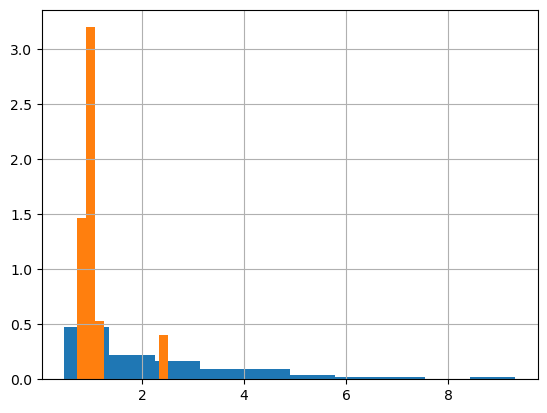

In [10]:
mane_iso_jac_tab.query('complementary == True').sp_to_domain_ratio.hist(density=True)
mane_iso_jac_tab.query('complementary == False').sp_to_domain_ratio.hist(density=True)

# one by one inspection of jacs

CHS.3483.5
CHS.3483.1


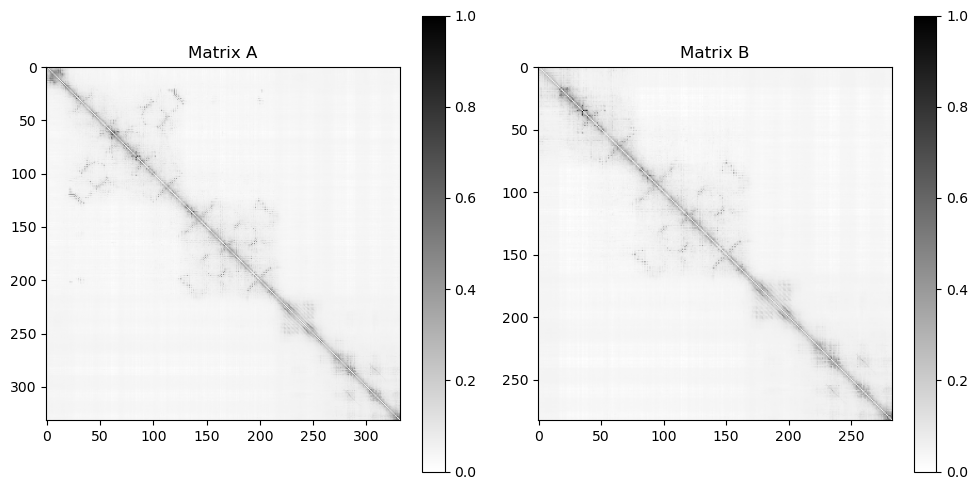

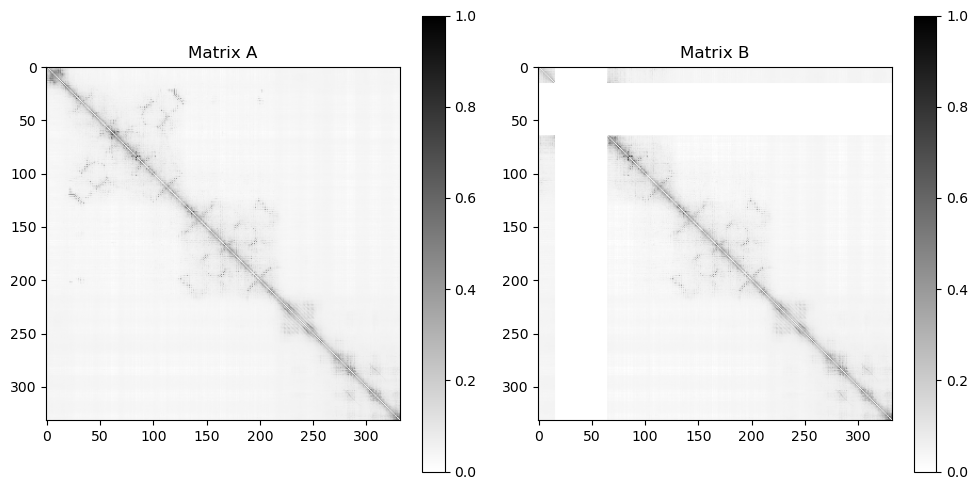

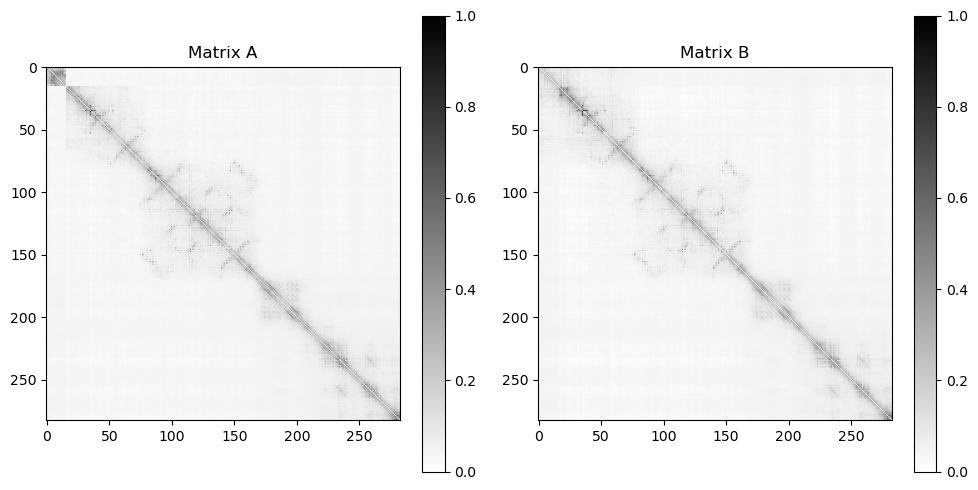

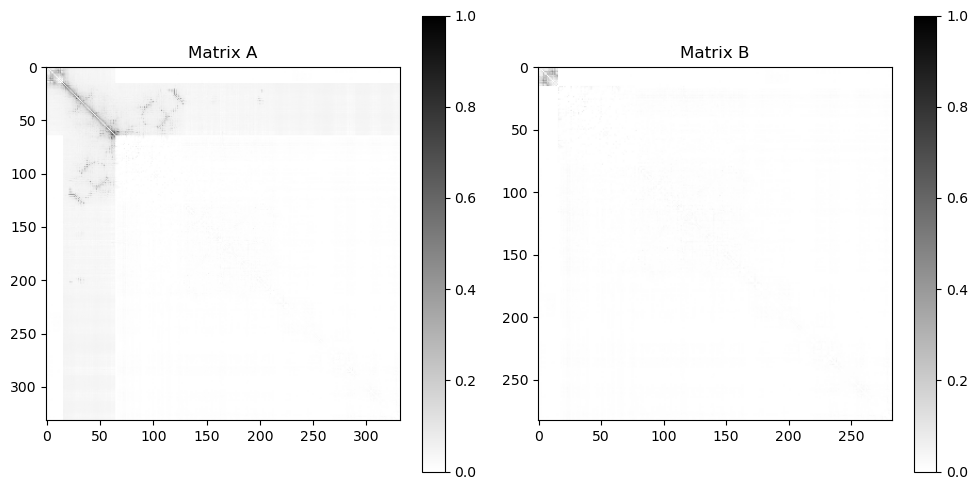

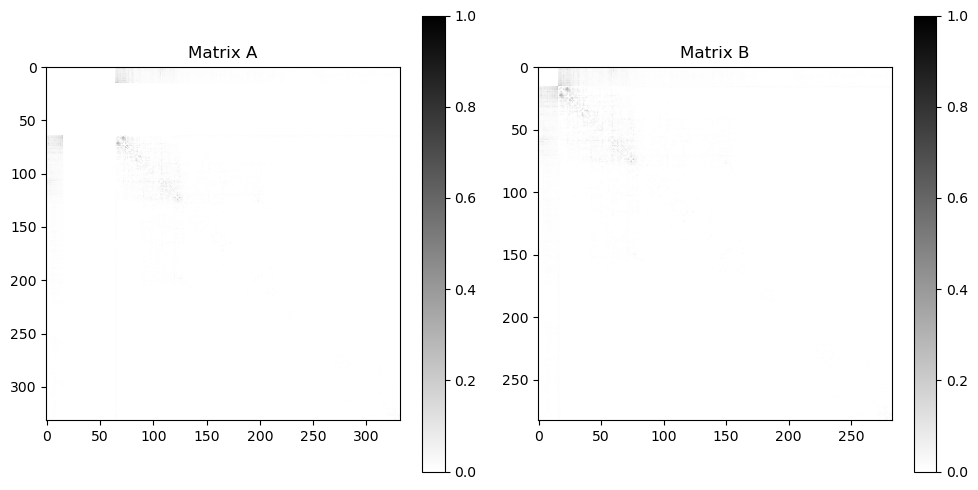

In [89]:
# # inspect figures one by one using chs ids 

# test_mane = "CHS.3483.5"
# test_iso = "CHS.3483.1"

# q = preprocess_alignment_for_jacobian_contacts(test_mane, test_iso)
# mane_jac, iso_jac = process_jacobian_contact_matrices_for_plotting(test_mane, test_iso, q[0])

# plt.imshow(mane_jac)
# mane_len = mane_jac.shape[0]
# print(mane_len)
# top_L_mane_jac = get_top_L_matrix_values(mane_jac, mane_len, 7.5)
# plt.imshow(top_L_mane_jac, cmap='gray_r', vmin = 0, vmax = 1)

# plt.imshow(iso_jac)
# iso_len = iso_jac.shape[0]
# print(iso_len)
# top_L_iso_jac = get_top_L_matrix_values(iso_jac, iso_len, 10)
# plt.imshow(top_L_iso_jac, cmap='gray_r', vmin = 0, vmax = 1)

# quant = 0.93
# mane_capped = cap_contacts_by_quantile(mane_jac, quant)
# print(mane_capped[0].shape)
# plt.imshow(mane_capped[0], cmap='gray_r', vmin = 0, vmax = 0.57)
